In [25]:
import pandas as pd

# load
df = pd.read_csv("../data/SMSSpamCollection", sep='\t', names=["label", "message"])

# clean
df = df.drop_duplicates()
df['message'] = df['message'].str.strip()
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

df.head()

,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [26]:
df.shape
df['label'].value_counts()

label
ham     4516
spam     653
Name: count, dtype: int64

Shape: (5169, 3)

Class Distribution:
 label
ham     4516
spam     653
Name: count, dtype: int64


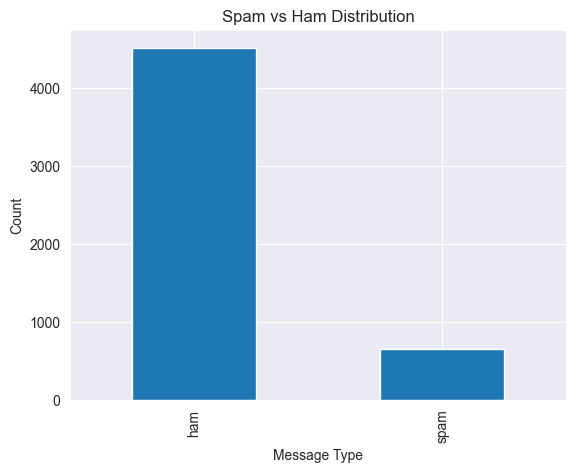

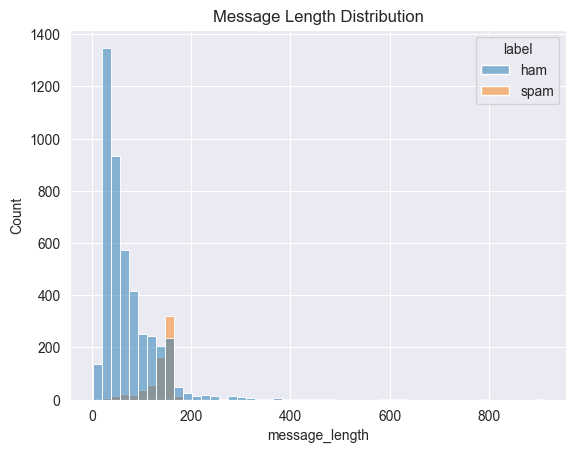

In [27]:
# eda
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")

# basic understanding
print("Shape:", df.shape)
print("\nClass Distribution:\n", df['label'].value_counts())

# ------------------------------
# 1. Spam vs Ham (MANDATORY)
# ------------------------------
df['label'].value_counts().plot(kind='bar')

plt.title("Spam vs Ham Distribution")
plt.xlabel("Message Type")
plt.ylabel("Count")

plt.savefig("../images/spam_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

# ------------------------------
# 2. Message Length (ONLY extra graph)
# ------------------------------
df['message_length'] = df['message'].apply(len)

sns.histplot(data=df, x='message_length', hue='label', bins=50)

plt.title("Message Length Distribution")

plt.savefig("../images/message_length.png", dpi=300, bbox_inches='tight')
plt.show()

In [28]:
# feature

import re

# word count
df['word_count'] = df['message'].apply(lambda x: len(x.split()))

# uppercase ratio
def uppercase_ratio(text):
    total = len(text)
    upper = sum(1 for c in text if c.isupper())
    return upper / total if total > 0 else 0

df['uppercase_ratio'] = df['message'].apply(uppercase_ratio)

# has link
df['has_link'] = df['message'].apply(lambda x: 1 if "http" in x or "www" in x else 0)

# digit count
df['digit_count'] = df['message'].apply(lambda x: sum(c.isdigit() for c in x))

# special characters
df['special_char_count'] = df['message'].apply(lambda x: len(re.findall(r'[^a-zA-Z0-9\s]', x)))

# keyword flag
spam_keywords = ['free', 'win', 'offer', 'click', 'buy', 'urgent', 'prize']

df['keyword_flag'] = df['message'].apply(
    lambda x: 1 if any(word in x.lower() for word in spam_keywords) else 0
)

df.head()

,label,message,label_num,message_length,word_count,uppercase_ratio,has_link,digit_count,special_char_count,keyword_flag
0,ham,"Go until jurong point, crazy.. Available only ...",0,111,20,0.027027,0,0,9,0
1,ham,Ok lar... Joking wif u oni...,0,29,6,0.068966,0,0,6,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,155,28,0.064516,0,25,6,1
3,ham,U dun say so early hor... U c already then say...,0,49,11,0.040816,0,0,6,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,61,13,0.032787,0,0,2,0


In [29]:
# tfidf

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=3000)

X_text = tfidf.fit_transform(df['message'])

X_text.shape

(5169, 3000)

In [30]:
# combine

X_numeric = df[['message_length', 'word_count', 'uppercase_ratio',
                'has_link', 'digit_count', 'special_char_count', 'keyword_flag']]

import numpy as np

X = np.hstack((X_text.toarray(), X_numeric.values))
y = df['label_num']

X.shape

(5169, 3007)

In [31]:
# split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((4135, 3007), (1034, 3007))

In [32]:
# train

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [33]:
# predict

y_pred = model.predict(X_test)

In [34]:
# evaluate

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.9854932301740812
Precision: 0.9921259842519685
Recall: 0.9
F1 Score: 0.9438202247191011


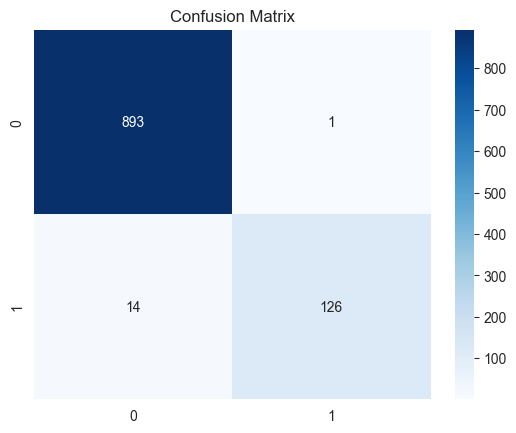

In [35]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

In [36]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(model, "../models/spam_model.pkl")
joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")

def predict_message(message):
    import pandas as pd
    import numpy as np
    import re

    msg_df = pd.DataFrame([message], columns=['message'])

    msg_df['message_length'] = msg_df['message'].apply(len)
    msg_df['word_count'] = msg_df['message'].apply(lambda x: len(x.split()))
    
    def uppercase_ratio(text):
        total = len(text)
        upper = sum(1 for c in text if c.isupper())
        return upper / total if total > 0 else 0

    msg_df['uppercase_ratio'] = msg_df['message'].apply(uppercase_ratio)
    msg_df['has_link'] = msg_df['message'].apply(lambda x: 1 if "http" in x or "www" in x else 0)
    msg_df['digit_count'] = msg_df['message'].apply(lambda x: sum(c.isdigit() for c in x))
    msg_df['special_char_count'] = msg_df['message'].apply(lambda x: len(re.findall(r'[^a-zA-Z0-9\s]', x)))

    spam_keywords = ['free', 'win', 'offer', 'click', 'buy', 'urgent', 'prize']

    msg_df['keyword_flag'] = msg_df['message'].apply(
        lambda x: 1 if any(word in x.lower() for word in spam_keywords) else 0
    )

    text_features = tfidf.transform(msg_df['message']).toarray()

    numeric_features = msg_df[['message_length', 'word_count', 'uppercase_ratio',
                              'has_link', 'digit_count', 'special_char_count', 'keyword_flag']].values

    final_input = np.hstack((text_features, numeric_features))

    prob = model.predict_proba(final_input)[0][1]
    pred = model.predict(final_input)[0]

    return {"prediction": "spam" if pred == 1 else "ham", "probability": prob}


print(predict_message("Congratulations! You won a free prize! Click now"))

{'prediction': 'ham', 'probability': np.float64(0.23)}
